# Comparison of Well Log Resistivity and 1D TEM Inversion Results

This notebook performs spatial matching between water wells/coal holes and binned TEM flight line soundings, extracts resistivity curves from LAS files, aligns them in depth, and plots comparative curves of well log resistivity vs the 1D inversion model.

In [1]:
import os
import sys
import geopandas as gpd
import pandas as pd
import numpy as np
import dill
import lasio as ls
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# Change working directory to project root if running from notebooks directory
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print(f"Current Working Directory: {os.getcwd()}")

# Add tools path to import binning function
sys.path.append("tools")
from tools import binning

from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
from simpeg.utils import plot_1d_layer_model

Current Working Directory: /Volumes/X31/01-Projects/atem


In [2]:
WELL_DATA_DIR = "data/well_data"
WATER_WELL_SHP = os.path.join(WELL_DATA_DIR, "WaterWell_HQ_LAS/WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp")
COAL_HOLE_SHP = os.path.join(WELL_DATA_DIR, "CoalHoles_HQ_LAS/CoalHoles_HQ_LAS/ShapeFile/CoalHole_CLC_HQ.shp")

# Load shapefiles
ww_gdf = gpd.read_file(WATER_WELL_SHP)
ch_gdf = gpd.read_file(COAL_HOLE_SHP)

# Convert to UTM Zone 12N (EPSG:26912) to match flight lines
ww_utm12 = ww_gdf.to_crs(epsg=26912)
ch_utm12 = ch_gdf.to_crs(epsg=26912)

print(f"Loaded {len(ww_gdf)} Water Wells and {len(ch_gdf)} Coal Holes.")

Loaded 25 Water Wells and 52 Coal Holes.


In [3]:
def find_matching_sounding(well_name, well_gdf_utm, df_binned, pik_path, dheader):
    """
    Finds the nearest sounding in the binned dataframe spatially,
    then runs a local search in the pik file to match the exact sounding index.
    """
    if 'Name' in well_gdf_utm.columns:
        well_row = well_gdf_utm[well_gdf_utm['Name'] == well_name].iloc[0]
    else:
        well_row = well_gdf_utm[well_gdf_utm['LAS_FI_NAM'] == well_name].iloc[0]
        
    well_xy = np.array([well_row.geometry.x, well_row.geometry.y])
    
    # 1. Spatial lookup in df_binned
    tree = cKDTree(df_binned[['x_wgs84', 'y_wgs84']].values)
    dist, idx_binned = tree.query(well_xy)
    
    # 2. Local search in .pik file
    with open(pik_path, "rb") as f:
        out_dict = dill.load(f)
    last_iter = max(out_dict.keys())
    m = out_dict[last_iter]['m']
    dpred = out_dict[last_iter]['dpred']
    n_layers = 22
    n_soundings_pik = int(m.shape[0] / n_layers)
    
    dpred_reshaped = np.abs(dpred.reshape((n_soundings_pik, n_layers))) + 1e-15
    dobs_abs = np.abs(df_binned[dheader].values[idx_binned]) + 1e-15
    
    search_start = max(0, idx_binned - 500)
    search_end = min(n_soundings_pik, idx_binned + 500)
    
    dpred_search = dpred_reshaped[search_start:search_end]
    diffs = np.sum((np.log10(dpred_search) - np.log10(dobs_abs))**2, axis=1)
    best_match_local_idx = np.argmin(diffs)
    idx_pik = search_start + best_match_local_idx
    
    rho_sounding = 1. / np.exp(m.reshape((n_soundings_pik, n_layers))[idx_pik])
    line = df_binned.iloc[idx_binned]['Line']
    dtm = df_binned.iloc[idx_binned]['dtm']
    
    print(f"Matched Well {well_name} -> Binned Sounding Index: {idx_binned}, Pik Index: {idx_pik}")
    print(f"Distance: {dist:.1f} m | Line: {line} | Topography Elevation: {dtm:.1f} m")
    
    return idx_pik, rho_sounding, dist, line, dtm

In [4]:
def load_well_las(well_name, well_type):
    """
    Loads LAS file and extracts valid depth and resistivity/conductivity logs.
    Converts conductivity to resistivity and re-scales depth if needed.
    """
    if well_type == "WaterWell":
        path = f"data/well_data/WaterWell_HQ_LAS/WaterWell_HQ_LAS/LAS_Files/{well_name}.las"
    else:
        path = f"data/well_data/CoalHoles_HQ_LAS/CoalHoles_HQ_LAS/LAS_Files/Litholog_{well_name}.las"
        if not os.path.exists(path):
            path = f"data/well_data/CoalHoles_HQ_LAS/CoalHoles_HQ_LAS/LAS_Files/Litholog_{well_name}_A.las"
            
    las = ls.read(path)
    df_las = las.df()
    
    depth = df_las.index.values
    # Detect units (assume meters by default, convert feet to meters if index units are feet)
    units = las.index_unit
    if units is None and len(las.curves) > 0:
        units = las.curves[0].unit
    if units is not None:
        units = str(units).upper()
        if 'FT' in units or 'FEET' in units:
            depth = depth * 0.3048
            print(f"  Converted depth from feet to meters for well {well_name}")
        
    res = None
    # Look for resistivity/conductivity curves
    for col in ['RES', 'RES1', 'RES2', 'SFR', 'CILD']:
        if col in df_las.columns:
            res_val = df_las[col].values
            if col == 'CILD':
                # Convert conductivity (mS/m) to resistivity (ohm-m): R = 1000 / C
                res_val = 1000.0 / (res_val + 1e-6)
                print(f"  Converted CILD (conductivity) to resistivity for {well_name}")
            res = res_val
            break
            
    if res is None:
        raise ValueError(f"No resistivity or conductivity curve found in well {well_name}")
        
    # Mask out negative or invalid values
    mask = (depth >= 0) & (res > 0) & (res < 10000)
    return depth[mask], res[mask]

In [5]:
def plot_comparison(well_name, well_type, area, line, dist, depth_well, res_well, res_sounding, dtm):
    """
    Plots the comparative analysis: well log resistivity and 1D TEM inversion model vs depth.
    """
    hz = get_vertical_discretization(21, 2, 1.17)
    
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # Plot well log
    ax.plot(res_well, depth_well, color='black', label=f'Well Log ({well_name})', linewidth=1.5)
    
    # Plot Simpeg 1D inversion model
    plot_1d_layer_model(hz, res_sounding, ax=ax, color='crimson', label='1D Inversion Model', linewidth=2)
    
    # Configure axes
    ax.set_xscale('log')
    ax.invert_yaxis()
    ax.set_xlabel(r'Resistivity ($\Omega \cdot m$)', fontsize=12)
    ax.set_ylabel('Depth (m)', fontsize=12)
    ax.set_title(f'Resistivity vs Depth Comparison\nArea: {area} | Well: {well_name} (Dist: {dist:.1f}m) | Line: {line}', fontsize=12)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='lower left', fontsize=10)
    
    # Set y-limits to the depth of the well log + 20m buffer
    max_depth = min(depth_well.max(), 320.0)
    ax.set_ylim([max_depth + 10.0, 0])
    
    plt.tight_layout()
    plt.show()

## 1. NE Area Comparison: Water Well `111913-a` vs NE Inversion

We load the NE area survey data, bin it using the exact parameters, and locate the nearest flight sounding to Water Well `111913-a` (distance: **12.5m**).

Running exact binning for NE...


Matched Well 111913-a -> Binned Sounding Index: 14717, Pik Index: 14713
Distance: 78.5 m | Line: L10160 | Topography Elevation: 789.9 m
  Converted depth from feet to meters for well 111913-a
>> Depth from the surface to the base of the bottom layer is 306.3m


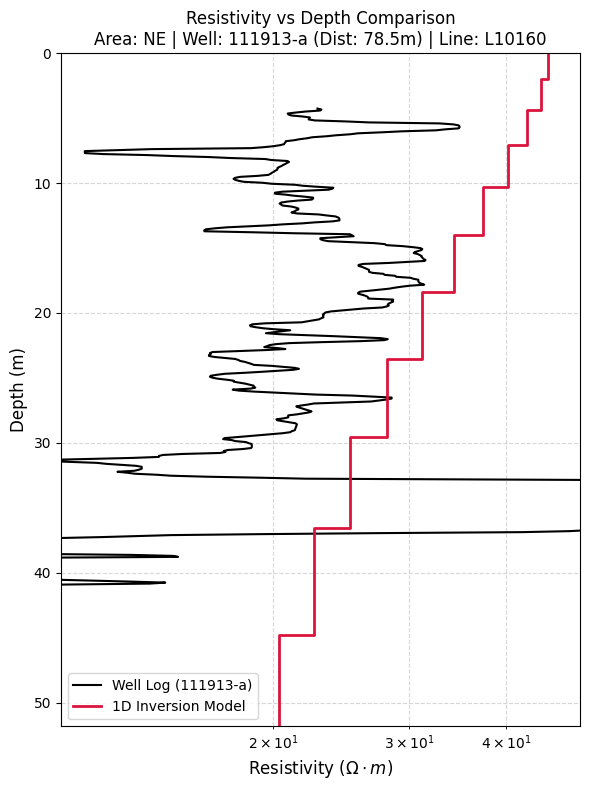

In [6]:
area = "NE"
pik_path = "data/archives/NE_inv_results_atem_full.pik"

# Run exact binning for NE
print("Running exact binning for NE...")
res_ne = binning(dx=50.0, area=area)
df_binned_ne = pd.DataFrame(
    data=np.vstack(res_ne["values"]), columns=["Line", "distance"] + res_ne["picker"][1:]
)
for col in df_binned_ne.columns:
    if col != "Line":
        df_binned_ne[col] = pd.to_numeric(df_binned_ne[col])

# Find matching sounding and plot
idx_pik, res_sounding, dist, line, dtm = find_matching_sounding(
    "111913-a", ww_utm12, df_binned_ne, pik_path, res_ne["dheader"]
)
depth_well, res_well = load_well_las("111913-a", "WaterWell")

plot_comparison("111913-a", "WaterWell", area, line, dist, depth_well, res_well, res_sounding, dtm)

## 2. SE Area Comparison 1: Water Well `153845-a` vs SE Inversion

We load the SE area survey data and locate the nearest flight sounding to Water Well `153845-a` (distance: **4.0m**).

Running exact binning for SE...


Matched Well 153845-a -> Binned Sounding Index: 82713, Pik Index: 82438
Distance: 17.1 m | Line: L20480 | Topography Elevation: 826.0 m
  Converted depth from feet to meters for well 153845-a
>> Depth from the surface to the base of the bottom layer is 306.3m


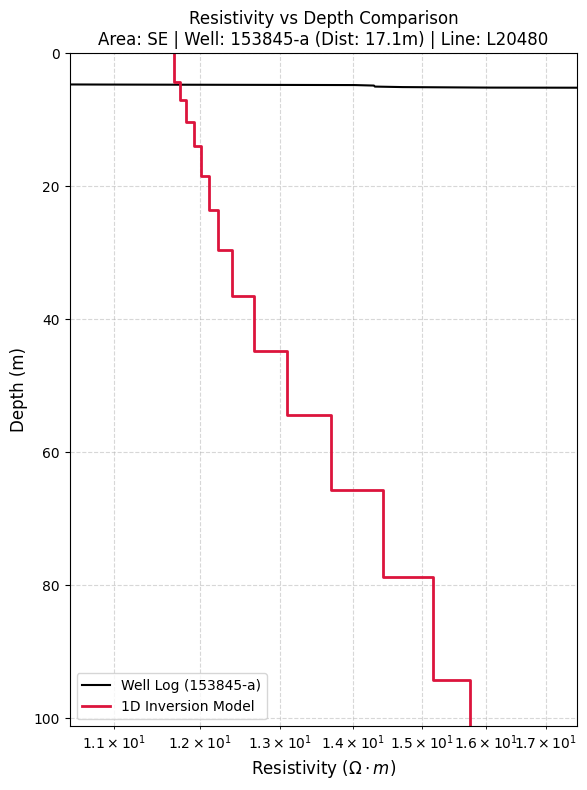

In [7]:
area = "SE"
pik_path = "data/archives/SE_inv_results_atem_full.pik"

# Run exact binning for SE
print("Running exact binning for SE...")
res_se = binning(dx=50.0, area=area)
df_binned_se = pd.DataFrame(
    data=np.vstack(res_se["values"]), columns=["Line", "distance"] + res_se["picker"][1:]
)
for col in df_binned_se.columns:
    if col != "Line":
        df_binned_se[col] = pd.to_numeric(df_binned_se[col])

# Find matching sounding and plot
idx_pik, res_sounding, dist, line, dtm = find_matching_sounding(
    "153845-a", ww_utm12, df_binned_se, pik_path, res_se["dheader"]
)
depth_well, res_well = load_well_las("153845-a", "WaterWell")

plot_comparison("153845-a", "WaterWell", area, line, dist, depth_well, res_well, res_sounding, dtm)

## 3. SE Area Comparison 2: Coal Hole `TH24-83` vs SE Inversion

We compare Coal Hole `TH24-83` with the SE inversion results (distance: **51.0m**).

Conflicting index units found: {'FT', 'M'}


Matched Well TH24-83 -> Binned Sounding Index: 21406, Pik Index: 20940
Distance: 51.5 m | Line: L20140 | Topography Elevation: 773.0 m
>> Depth from the surface to the base of the bottom layer is 306.3m


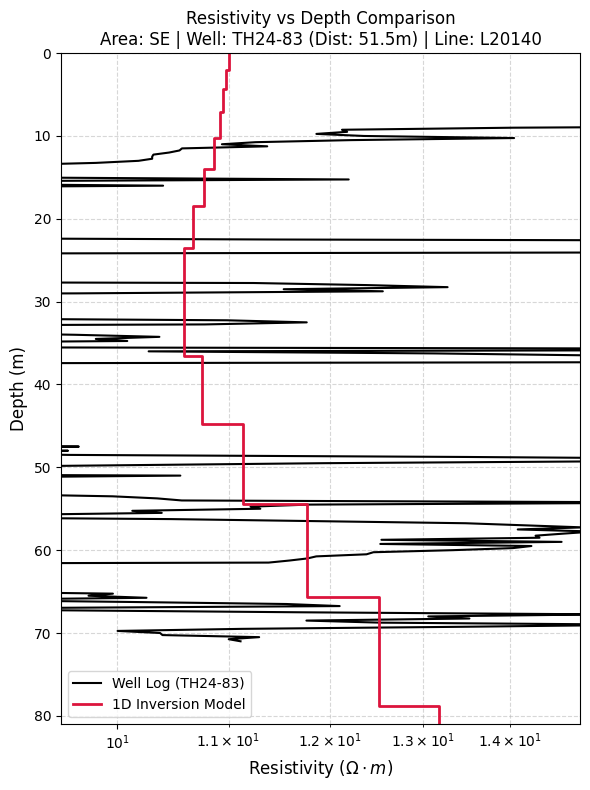

In [8]:
# Find matching sounding and plot for Coal Hole TH24-83 using the already binned SE data
idx_pik, res_sounding, dist, line, dtm = find_matching_sounding(
    "TH24-83", ch_utm12, df_binned_se, pik_path, res_se["dheader"]
)
depth_well, res_well = load_well_las("TH24-83", "CoalHole")

plot_comparison("TH24-83", "CoalHole", area, line, dist, depth_well, res_well, res_sounding, dtm)

## 4. NW Area Comparison: Water Well `111800-a` vs NW Inversion

We load the NW area survey data and locate the nearest flight sounding to Water Well `111800-a` (distance: **180.5m**).

Running exact binning for NW...


Matched Well 111800-a -> Binned Sounding Index: 23951, Pik Index: 24138
Distance: 181.4 m | Line: L10920 | Topography Elevation: 955.0 m
  Converted depth from feet to meters for well 111800-a
>> Depth from the surface to the base of the bottom layer is 306.3m


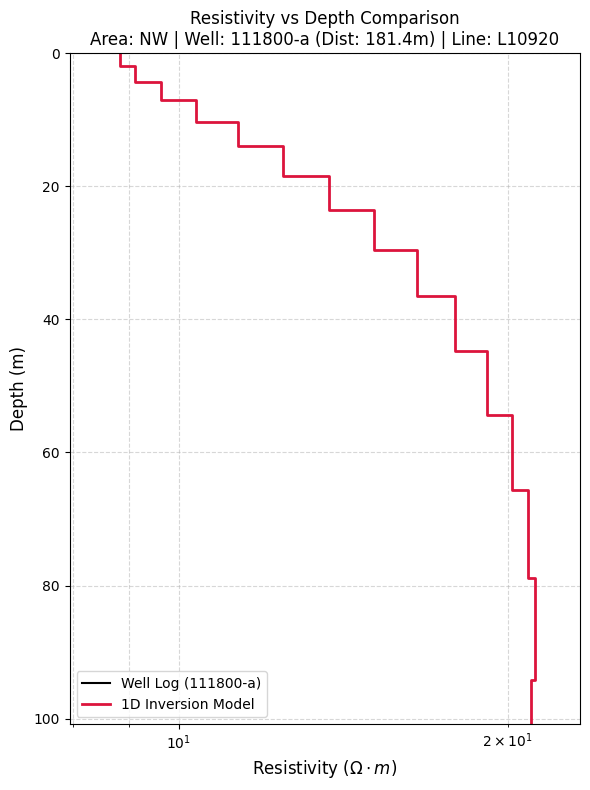

In [9]:
area = "NW"
pik_path = "data/archives/NW_inv_results_atem_full.pik"

# Run exact binning for NW
print("Running exact binning for NW...")
res_nw = binning(dx=50.0, area=area)
df_binned_nw = pd.DataFrame(
    data=np.vstack(res_nw["values"]), columns=["Line", "distance"] + res_nw["picker"][1:]
)
for col in df_binned_nw.columns:
    if col != "Line":
        df_binned_nw[col] = pd.to_numeric(df_binned_nw[col])

# Find matching sounding and plot
idx_pik, res_sounding, dist, line, dtm = find_matching_sounding(
    "111800-a", ww_utm12, df_binned_nw, pik_path, res_nw["dheader"]
)
depth_well, res_well = load_well_las("111800-a", "WaterWell")

plot_comparison("111800-a", "WaterWell", area, line, dist, depth_well, res_well, res_sounding, dtm)